# Random action agent

In [1]:
import pprint
from Environment.simulator import *
from Environment.my_utils import *
from stable_baselines3.common.env_checker import check_env

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Replicate runs
TEST_EPISODES = 10

# SIM PARAMETERS
SLA = 0.5
VM_TYPE1 = 5
VM_TYPE2 = 3
VM_TYPE3 = 1
STEPS = 100
ALPHA = 0.5
BETA = 0.5

env = Sim(sla = SLA,
          vm_1 = VM_TYPE1,
          vm_2 = VM_TYPE2,
          vm_3 = VM_TYPE3,
          steps = STEPS,
          alpha = ALPHA,
          beta = BETA)

Check if my custom enivorment correctly follow OpenAI Gym structure

In [3]:
#check_env(env, warn=0, skip_render_check=1)

In [4]:
def run_episode(print_info=False):
    state = env.reset()
    done = False
    score = 0 
    while not done:
        action = env.action_space.sample()
        n_state, reward, done, info = env.step(action)
        
        if print_info:
            pp = pprint.PrettyPrinter(indent=5)
            print("Action: ", action)
            print("Reward: ", reward)
            print("Next state: ", n_state)
            pp.pprint(info)
            print("-----------------------------------------")
        
        score+=reward
    return score

Run single episode and look up detailed information step by step

In [5]:
run_episode(print_info=True)

Action:  5
Reward:  0
Next state:  [40.835]
{    'Current cost': 81.67,
     'Quality of Service': 0.5514,
     'Queue len': 10,
     'Timer': 5.513915538787842,
     'VM type I': 5,
     'VM type II': 2,
     'VM type III': 1}
-----------------------------------------
Action:  4
Reward:  0
Next state:  [57.9175]
{    'Current cost': 75.0,
     'Quality of Service': 0.6138,
     'Queue len': 11,
     'Timer': 6.751607179641724,
     'VM type I': 4,
     'VM type II': 2,
     'VM type III': 1}
-----------------------------------------
Action:  3
Reward:  -1
Next state:  [203.95876]
{    'Current cost': 150.0,
     'Quality of Service': 0.2478,
     'Queue len': 12,
     'Timer': 2.9732749462127686,
     'VM type I': 4,
     'VM type II': 2,
     'VM type III': 4}
-----------------------------------------
Action:  3
Reward:  -1
Next state:  [276.97937]
{    'Current cost': 150.0,
     'Quality of Service': 0.1142,
     'Queue len': 12,
     'Timer': 1.3700103759765625,
     'VM type I': 

Action:  0
Reward:  -1
Next state:  [346.1326]
{    'Current cost': 153.33,
     'Quality of Service': 0.3606,
     'Queue len': 15,
     'Timer': 5.4090211391448975,
     'VM type I': 8,
     'VM type II': 0,
     'VM type III': 4}
-----------------------------------------
Action:  1
Reward:  -1
Next state:  [353.06628]
{    'Current cost': 160.0,
     'Quality of Service': 0.2387,
     'Queue len': 12,
     'Timer': 2.864448070526123,
     'VM type I': 9,
     'VM type II': 0,
     'VM type III': 4}
-----------------------------------------
Action:  1
Reward:  -1
Next state:  [359.86813]
{    'Current cost': 166.67,
     'Quality of Service': 0.0556,
     'Queue len': 14,
     'Timer': 0.7789239883422852,
     'VM type I': 10,
     'VM type II': 0,
     'VM type III': 4}
-----------------------------------------
Action:  1
Reward:  -1
Next state:  [366.59906]
{    'Current cost': 173.33,
     'Quality of Service': 0.2763,
     'Queue len': 15,
     'Timer': 4.143779993057251,
     'V

Action:  6
Reward:  -1
Next state:  [341.2499]
{    'Current cost': 128.33,
     'Quality of Service': 0.1899,
     'Queue len': 15,
     'Timer': 2.848127603530884,
     'VM type I': 10,
     'VM type II': 1,
     'VM type III': 2}
-----------------------------------------
Action:  0
Reward:  -1
Next state:  [334.78995]
{    'Current cost': 128.33,
     'Quality of Service': 0.4137,
     'Queue len': 13,
     'Timer': 5.377956867218018,
     'VM type I': 10,
     'VM type II': 1,
     'VM type III': 2}
-----------------------------------------
Action:  2
Reward:  -1
Next state:  [337.395]
{    'Current cost': 140.0,
     'Quality of Service': 0.2921,
     'Queue len': 10,
     'Timer': 2.9206225872039795,
     'VM type I': 10,
     'VM type II': 2,
     'VM type III': 2}
-----------------------------------------
Action:  4
Reward:  -1
Next state:  [335.3625]
{    'Current cost': 133.33,
     'Quality of Service': 0.4352,
     'Queue len': 15,
     'Timer': 6.527597188949585,
     'VM 

Action:  5
Reward:  -1
Next state:  [339.125]
{    'Current cost': 166.67,
     'Quality of Service': 0.4652,
     'Queue len': 14,
     'Timer': 6.512699365615845,
     'VM type I': 5,
     'VM type II': 5,
     'VM type III': 3}
-----------------------------------------
Action:  4
Reward:  -1
Next state:  [349.5625]
{    'Current cost': 160.0,
     'Quality of Service': 0.2176,
     'Queue len': 13,
     'Timer': 2.828915596008301,
     'VM type I': 4,
     'VM type II': 5,
     'VM type III': 3}
-----------------------------------------
Action:  6
Reward:  -1
Next state:  [342.28125]
{    'Current cost': 135.0,
     'Quality of Service': 0.2486,
     'Queue len': 14,
     'Timer': 3.4798474311828613,
     'VM type I': 4,
     'VM type II': 5,
     'VM type III': 2}
-----------------------------------------
Action:  4
Reward:  -1
Next state:  [335.30563]
{    'Current cost': 128.33,
     'Quality of Service': 0.2307,
     'Queue len': 12,
     'Timer': 2.7680795192718506,
     'VM ty

-71

Run 10 episodes (with no detailed information)

In [6]:
scores = []
episodes = []

for episode in range(1, TEST_EPISODES+1):
    score = run_episode(print_info=False)
    scores.append(score)
    episodes.append(episode)
    print('Episode:{} Score:{}'.format(episode, score))

Episode:1 Score:-84
Episode:2 Score:-80
Episode:3 Score:-62
Episode:4 Score:-73
Episode:5 Score:-81
Episode:6 Score:-75
Episode:7 Score:-85
Episode:8 Score:-75
Episode:9 Score:-77
Episode:10 Score:-94


Vizualize performce on sample episode

In [7]:
# restart env
obs = env.reset()
done = False

# 
culumative_reward = 0
step = 0
value = []
quality_of_service = []
utility_function = []
queue_len = []
cost_lst = []
no_of_vm_lst = []
steps_lst = []

while True:
    action = env.action_space.sample()
    obs, rewards, done, info = env.step(action)
    
    # save the resuls
    culumative_reward+=rewards
    step +=1
    value.append(culumative_reward)
    steps_lst.append(step)
    quality_of_service.append(info['Quality of Service'])
    utility_function.append(obs)
    cost_lst.append(info['Current cost'])
    no_of_vm_lst.append(info['VM type I'] + info['VM type II'] + info['VM type III'])
    queue_len.append(info['Queue len'])
    
    if done: 
        print('info', info)
        break

info {'Quality of Service': 0.1661, 'Current cost': 138.33, 'Queue len': 15, 'Timer': 2.4912302494049072, 'VM type I': 1, 'VM type II': 7, 'VM type III': 2}


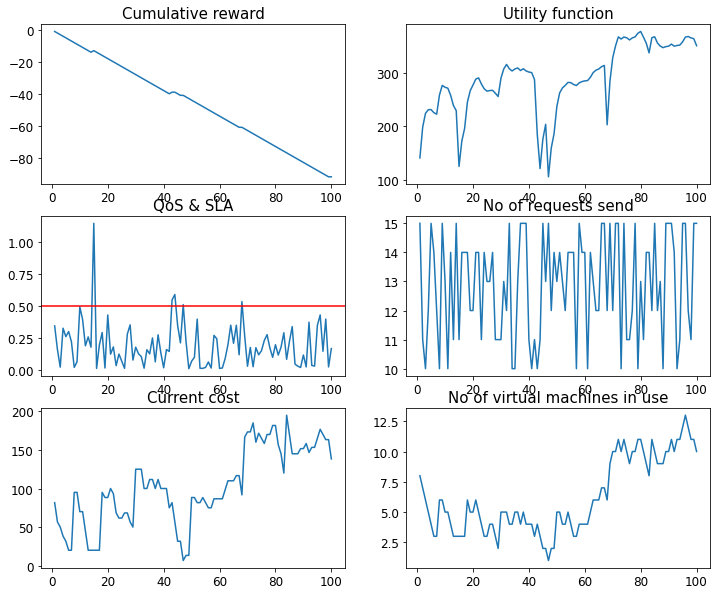

In [9]:
viz_performance(cumulative_reward=value,
               utility_function=utility_function,
               qos=quality_of_service,
               queue_len=queue_len,
               cost = cost_lst,
               no_of_vm = no_of_vm_lst,
               steps=steps_lst,
               sla=SLA)